In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as c
from scipy.signal import fftconvolve
from q3dfit.q3din import q3din
from q3dfit.q3dout import q3dout, load_q3dout
from q3dfit.q3df import q3dfit
from q3dfit import q3dutil
from q3dfit.checkcomp import checkcomp
from q3dfit.q3dcollect import q3dcollect
from q3dfit.linelist import linelist
from powerbin import PowerBin

In [6]:
NCORES = 22

def makedir(*dirs):
    for d in dirs:
        if not os.path.exists(d):
            os.makedirs(d)

def init_fit_single(
        infile: str, 
        label: str, 
        lines: list[str],
        outdir: str,
        redshift: float, 
        fitrange: list[float],
        dirlabel: str = "single"
        ) -> q3din:
    
    # set up directories
    indir = os.path.join(outdir, "input")
    outdir_n = os.path.join(outdir, f"output_{dirlabel}")
    logdir_n = os.path.join(outdir, f"logfiles_{dirlabel}")
    makedir(indir, outdir_n, logdir_n)

    logfile = os.path.join(logdir_n, label+"-fitlog.txt")
    q3di = q3din(infile, label, outdir=outdir_n, logfile=logfile)
    q3di.argsreadcube = {"wmapext": None, "fluxnorm": 1e-17, "usebunit": True}
    cube = q3di.load_cube()
    q3di.name = label
    q3di.zsys_gas = redshift
    q3di.fitrange = fitrange

    # line fit
    q3di.init_linefit(lines, linetie=lines[0], maxncomp=1, checkcomp=True)
    q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
    q3di.siglim_gas = np.array([50., 1000.])
    # q3di.argslineinit['flxlim'] = np.array([0., 1e-14]) / cube.fluxnorm
    q3di.argslinefit['method'] = 'least_squares'
    q3di.argslinefit['ftol'] = 1.e-8
    q3di.argslinefit['gtol'] = 1.e-8
    q3di.argslinefit['xtol'] = 1.e-8
    q3di.argslinefit['x_scale'] = 'jac'
    q3di.argslinefit['tr_solver'] = 'lsmr'

    q3di.argscheckcomp['sigcut'] = 3.
    # q3di.argscheckcomp['ignore']= ['Hbeta']
    q3di.perror_useresid = True

    q3di.snr = 3.0
    q3di.snr_thresh = None

    for line in lines:
        q3di.zinit_gas[line][:,:] = q3di.zsys_gas

    # continum fit
    q3di.init_contfit("fitpoly")
    q3di.argscontfit.update({"fitord": 1})
    q3di.maskwidths_def = 2000
    q3di.masksig_secondfit = 4

    filename_q3di = os.path.join(indir, f"q3di_{label}_{dirlabel}.npy")
    q3di.filename = filename_q3di
    np.save(filename_q3di, q3di)
    return q3di

In [7]:
OII_data = {
    "infile": "4C1971_G235H_NRS1_NRS2_s3d.fits",
    "label": "4C1971",
    "lines": ["[OII]3726"],
    "outdir": "OII",
    "redshift": 3.5892,
    "fitrange": [1.67, 1.73]
}
cols, rows = None, None
q3di = init_fit_single(**OII_data)

Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: MJy/sr
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.


In [11]:
q3dfit(q3di.filename, cols, rows, onefit=True, quiet=True, ncores=NCORES, nocrash=True)
q3dcollect(q3di.filename, cols, rows, compsortpar=None, quiet=True)

Core 12: # spaxels fit=264
Core 10: # spaxels fit=264
Core 21: # spaxels fit=264
Core 20: # spaxels fit=264
Core 4: # spaxels fit=264
Core 7: # spaxels fit=264
Core 11: # spaxels fit=265
Core 1: # spaxels fit=264
Core 9: # spaxels fit=264
Core 2: # spaxels fit=264
Core 14: # spaxels fit=264
Core 13: # spaxels fit=264
Core 18: # spaxels fit=264
Core 15: # spaxels fit=264
Core 17: # spaxels fit=264
Core 8: # spaxels fit=264
Core 3: # spaxels fit=264
Core 5: # spaxels fit=264
Core 22: # spaxels fit=265
Core 16: # spaxels fit=264
Core 19: # spaxels fit=264
Core 6: # spaxels fit=264
Not sorting components
        No data for [1, 1]
        No data for [1, 2]
        No data for [1, 3]
        No data for [1, 4]
        No data for [1, 5]
        No data for [1, 74]
        No data for [1, 75]
        No data for [1, 76]
        No data for [1, 77]
        No data for [1, 78]
        No data for [1, 79]
        No data for [1, 80]
        No data for [1, 81]
        No data for [1, 82]
     

/tmp/ipykernel_10599/3290936048.py:13: RuntimeWarning: invalid value encountered in divide
  snr = emlflx["ftot"]["[OII]3726"]/emlflxerr["ftot"]["[OII]3726"]


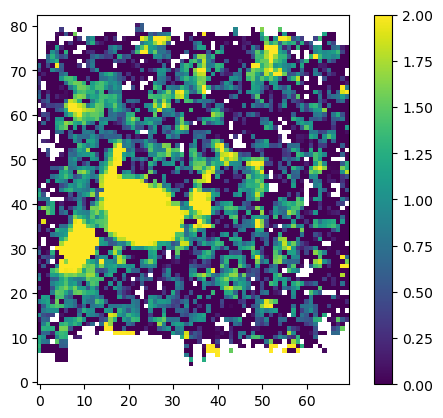

In [3]:
dataread = np.load("OII/output_single/4C1971.line.npz", allow_pickle=True)
emlflx = dataread['emlflx'].item()
emlflxerr = dataread['emlflxerr'].item()
# emlncomp = dataread['emlncomp'].item()
emlsig = dataread['emlsig'].item()
# emlsigerr = dataread['emlsigerr'].item()
# emlwav = dataread['emlwav'].item()
# emlwaverr = dataread['emlwaverr'].item()
# emlweq = dataread['emlweq'].item()
# ncols = dataread['ncols'].item()
# nrows = dataread['nrows'].item()
emlflx["ftot"]["[OII]3726"][np.isclose(emlsig["c1"]["[OII]3726"], 50., atol=1e-4)] = 0.
snr = emlflx["ftot"]["[OII]3726"]/emlflxerr["ftot"]["[OII]3726"]
# plt.imshow(emlflx["ftot"]["[OII]3726"].T, origin="lower", vmax=0.1)
plt.imshow(snr.T, origin="lower", vmax=2)
plt.colorbar()

/tmp/ipykernel_10741/2381296418.py:5: RuntimeWarning: invalid value encountered in divide
  snr_Hb = emlflx["ftot"]["Hbeta"]/emlflxerr["ftot"]["Hbeta"]


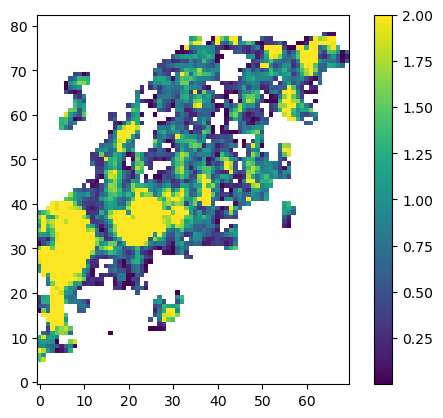

In [3]:
dataread = np.load("4C1971_neighbour_method.line.red.npz", allow_pickle=True)
emlflx = dataread['emlflx'].item()
emlflxerr = dataread['emlflxerr'].item()

snr_Hb = emlflx["ftot"]["Hbeta"]/emlflxerr["ftot"]["Hbeta"]
plt.imshow(snr_Hb.T, origin="lower", vmax=2)
plt.colorbar()

In [4]:
from q3dinterface import Q3DInterface
import tkinter as tk
window = tk.Tk()
Q3DInterface(window, "4C1971_from_OIII_binned", True, "Halpha", snr_Hb.T)
def on_closing():
    window.quit()
    window.destroy()
window.protocol("WM_DELETE_WINDOW", on_closing)
window.mainloop()

/home/daniel/python/q3dfit/q3dfit/q3dout.py:422: RuntimeWarning: invalid value encountered in scalar divide
  sigmaerr_obs[line][i] = self.perror[isigma] * \
/home/daniel/python/q3dfit/q3dfit/q3dmath.py:296: RuntimeWarning: invalid value encountered in scalar divide
  fluxerr = flux*np.sqrt((normerr/norm)**2. + (sigerr/sigma)**2.)
/home/daniel/python/q3dfit/q3dfit/q3dout.py:422: RuntimeWarning: invalid value encountered in scalar divide
  sigmaerr_obs[line][i] = self.perror[isigma] * \
/home/daniel/python/q3dfit/q3dfit/q3dmath.py:296: RuntimeWarning: invalid value encountered in scalar divide
  fluxerr = flux*np.sqrt((normerr/norm)**2. + (sigerr/sigma)**2.)
/home/daniel/python/q3dfit/q3dfit/q3dout.py:422: RuntimeWarning: invalid value encountered in scalar divide
  sigmaerr_obs[line][i] = self.perror[isigma] * \
/home/daniel/python/q3dfit/q3dfit/q3dmath.py:296: RuntimeWarning: invalid value encountered in scalar divide
  fluxerr = flux*np.sqrt((normerr/norm)**2. + (sigerr/sigma)**2.)
/

<Figure size 640x480 with 0 Axes>

In [4]:
snr = snr_Hb
snr[np.isnan(snr)] = 0.0

In [13]:
cube, vormap = q3dutil.get_Cube(q3di)
nspax, colarr, rowarr = q3dutil.get_spaxels(cube)
xy = np.column_stack([colarr, rowarr])
target_snr = 5

In [14]:
pow = PowerBin(xy, snr.flatten()**2, target_capacity=target_snr**2)

Bin-accretion Delaunay...
254  initial bins.
236  good bins.
Regularization...
Bins: 236; Single Pixels: 52/5810
Capacity Fractional RMS Scatter (%): 55.70
Time Accretion: 0.35 s
Time Regularization (it=49): 0.64 s


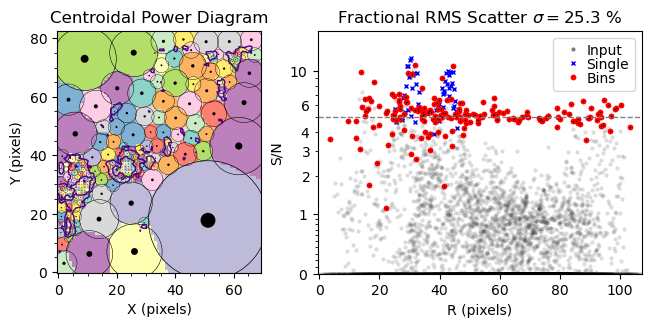

In [15]:
pow.plot(capacity_scale='sqrt', ylabel='S/N', magrange=2)

plt.show()

In [16]:
labels = pow.bin_num.reshape(snr.shape).T

In [18]:
np.save("binned_map_2.npy", labels.T)

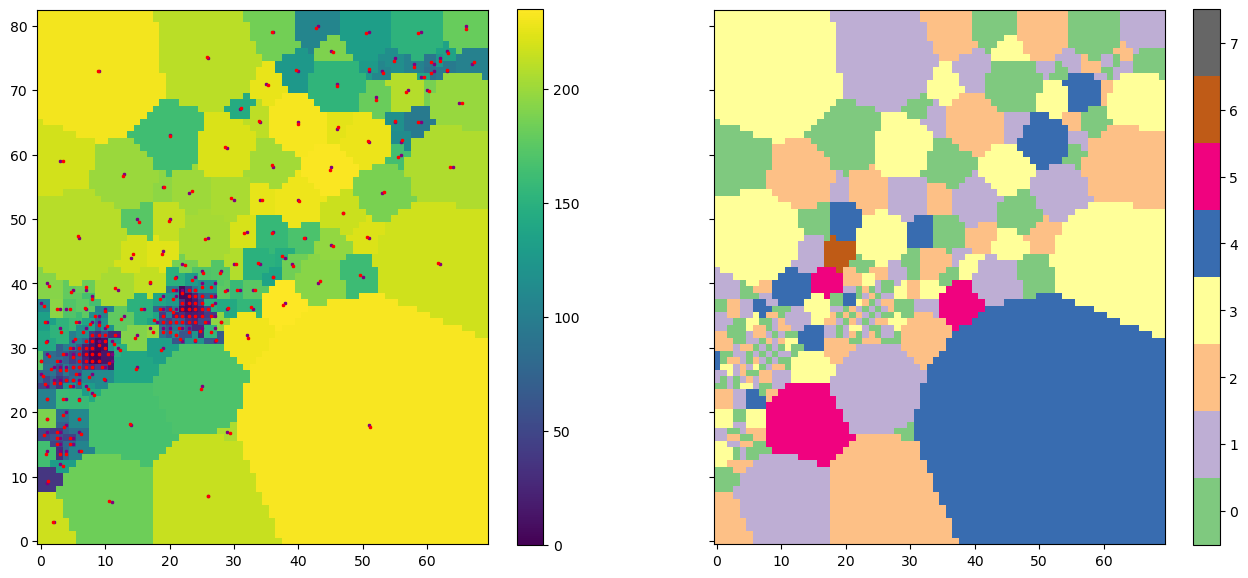

In [54]:
"https://github.com/bougui505/4-colors"
import scipy.ndimage

def get_neighbor_regions(labels, label):
    """
    labels: 2D array of labels as generated by generate_input
    label: Region to compute the neighbors of
    """
    boolsel = scipy.ndimage.morphology.binary_dilation(labels == label)
    neighbor_labels = set(np.unique(labels[boolsel]))
    neighbor_labels -= set([label, ])
    return neighbor_labels


def relabel(labels, background_label=None):
    """
    labels: 2D array of labels as generated by generate_input
    """
    labellist = set(np.unique(labels))
    nlabels = len(labellist)
    if background_label is not None:
        labellist -= set([background_label, ])
    out = labels.copy() * nlabels
    colors = set(range(nlabels))
    for label in labellist:
        label *= nlabels
        neighbor_labels = get_neighbor_regions(out, label)
        colors_ = colors - set(neighbor_labels)
        out[out == label] = list(colors_)[0]
    return out

out = relabel(labels)
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(16,8))
pcm = ax1.imshow(labels, origin="lower")
f.colorbar(pcm, ax=ax1, shrink=0.869)
pcm = ax2.imshow(out, origin="lower", cmap=plt.get_cmap('Accent'), vmin=-0.5, vmax=7.5)
f.colorbar(pcm, ax=ax2, shrink=0.869)
ax1.scatter(*np.floor(pow.xybin + 0.5).T, s=3, marker="x", color="purple")
ax1.scatter(*pow.xybin.T, s=3, marker="x", color="red")
plt.show()

In [55]:
data = cube.dat
var = cube.var
cols, rows = np.floor(pow.xybin + 0.5).T.astype(int)
bin_map = pow.bin_num.reshape(snr.shape)
binned_data = np.zeros_like(data, dtype=float)
binned_var = np.zeros_like(var, dtype=float)
for i, (c, r) in enumerate(zip(cols, rows)):
    binned_data[bin_map == i,:] = np.nansum(data[bin_map == i,:], axis=0)
    binned_var[bin_map == i,:] = np.nansum(var[bin_map == i,:], axis=0)

In [56]:
cols, rows = np.floor(pow.xybin + 0.5).T.astype(int)
np.save("colsrows_2.npy", np.stack((cols, rows)))

In [57]:
from astropy.io import fits
with fits.open("4C1971_G235H_NRS1_NRS2_s3d.fits") as hdul:
    hdul.info()
    hdul[1].data = binned_data.T * cube.fluxnorm
    hdul[1].header["BUNIT"] = "erg/s/cm2/micron"
    hdul[2].data = binned_var.T * cube.fluxnorm**2
    hdul[2].header["BUNIT"] = "erg/s/cm2/micron"
    hdul.writeto("4C1971_binned_2.fits", overwrite=True)

Filename: 4C1971_G235H_NRS1_NRS2_s3d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     374   ()      
  1  SCI           1 ImageHDU        34   (70, 83, 3815)   float64   
  2  SCI           1 ImageHDU        34   (70, 83, 3815)   float64   
  3                1 ImageHDU         8   (70, 83, 3815)   float64   


In [15]:
OII_data_binned = {
    "infile": "4C1971_binned.fits",
    "label": "4C1971",
    "lines": ["[OII]3726"],
    "outdir": "OII",
    "redshift": 3.5892,
    "fitrange": [1.67, 1.73],
    "dirlabel": "binned"
}
q3di = init_fit_single(**OII_data_binned)

Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.


In [16]:
cols, rows = cols.tolist(), rows.tolist()
q3dfit(q3di.filename, cols, rows, onefit=True, quiet=True, ncores=NCORES, nocrash=True)
q3dcollect(q3di.filename, cols, rows, compsortpar=None, quiet=True)

Core 16: # spaxels fit=14Core 21: # spaxels fit=14

Core 15: # spaxels fit=14
Core 10: # spaxels fit=14
Core 1: # spaxels fit=13
Core 6: # spaxels fit=13
Core 22: # spaxels fit=14
Core 14: # spaxels fit=13
Core 3: # spaxels fit=13
Core 9: # spaxels fit=13
Core 4: # spaxels fit=14
Core 2: # spaxels fit=14
Core 13: # spaxels fit=14
Core 20: # spaxels fit=13
Core 17: # spaxels fit=13
Core 5: # spaxels fit=14
Core 8: # spaxels fit=14
Core 18: # spaxels fit=14
Core 7: # spaxels fit=14
Core 19: # spaxels fit=14
Core 11: # spaxels fit=14
Core 12: # spaxels fit=13
Not sorting components
q3dcollect: Saving emission-line fit results into OII/output_binned/4C1971.line.npz
q3dcollect: Saving continuum fit results into OII/output_binned/4C1971.cont.npy


/tmp/ipykernel_8028/2992899131.py:12: RuntimeWarning: invalid value encountered in divide
  snr = emlflx["ftot"]["[OII]3726"]/emlflxerr["ftot"]["[OII]3726"]


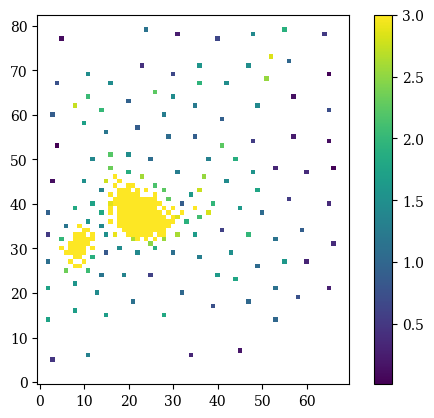

In [7]:
dataread = np.load("OII/output_binned/4C1971.line.npz", allow_pickle=True)
emlflx = dataread['emlflx'].item()
emlflxerr = dataread['emlflxerr'].item()
# emlncomp = dataread['emlncomp'].item()
# emlsig = dataread['emlsig'].item()
# emlsigerr = dataread['emlsigerr'].item()
# emlwav = dataread['emlwav'].item()
# emlwaverr = dataread['emlwaverr'].item()
# emlweq = dataread['emlweq'].item()
# ncols = dataread['ncols'].item()
# nrows = dataread['nrows'].item()
snr = emlflx["ftot"]["[OII]3726"]/emlflxerr["ftot"]["[OII]3726"]
plt.imshow(snr.T, origin="lower", vmax=3)
plt.colorbar()

In [9]:
import tkinter as tk
window = tk.Tk()
Q3DInterface(window, "4C1971_binned", True, "OII", snr.T)
def on_closing():
    window.quit()
    window.destroy()
window.protocol("WM_DELETE_WINDOW", on_closing)
window.mainloop()

<Figure size 640x480 with 0 Axes>